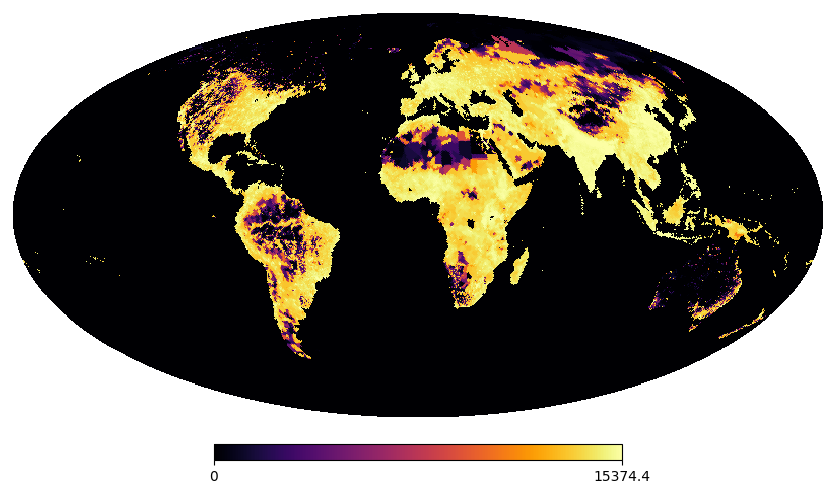

In [2]:
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
import tifffile as tiff

image = tiff.imread('./gpw_v4_population_density_adjusted_to_2015_unwpp_country_totals_rev11_2020_15_min.tif')
image_array = np.array(image)

theta = np.linspace(np.radians(0), np.radians(180), num=image_array.shape[0], endpoint=False)
phi = np.linspace(-np.radians(180), np.radians(180), num=image_array.shape[1], endpoint=False)

nside = 128
healpix_map = np.zeros(hp.nside2npix(nside), dtype=np.double)
pixel_counts = np.zeros(hp.nside2npix(nside), dtype=int)

for i in range(len(theta)):
    for j in range(len(phi)):
        pixel = hp.ang2pix(nside, theta[i], phi[j])
        healpix_map[pixel] += image_array[i, j]
        pixel_counts[pixel] += 1

healpix_map[pixel_counts > 0] /= pixel_counts[pixel_counts > 0]
healpix_map[healpix_map<0]=0
hp.mollview(healpix_map,flip='geo',norm='hist',cmap='inferno',title='')
plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/pop_final.pdf',format='pdf',dpi=600)
